# Column Detection — Test Notebook

Everything comes from `agent.py` — one import.  
Results are persisted automatically to `detections.db` (SQLite).

**Kernel**: `yolo` conda environment

In [1]:
import sys, json, importlib
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image

sys.path.insert(0, str(Path(".").resolve()))
import agent
print("agent.py loaded OK")

agent.py loaded OK


## 1 — Environment check

In [2]:
print(json.dumps(agent.get_status(), indent=2))

{
  "ollama": "ok",
  "model": "moondream:latest",
  "available": [
    "qwen3.5:0.8b",
    "deepseek-coder-v2:16b",
    "mistral:7b",
    "qwen2.5vl:3b",
    "llava-llama3:8b",
    "llava-llama3:latest",
    "llava:7b-v1.6",
    "llava:7b",
    "qwen3.5:2b",
    "qwen2.5vl:7b",
    "llama3.1:8b",
    "qwen3-vl:8b",
    "minimax-m2.5:cloud",
    "moondream:latest"
  ]
}


## 2 — Ground-truth reference images

Drop any new column image into `ground_truth/columns/` and call `references_reload()`.  
Filenames are matched to shapes automatically (keywords: square/rect/round/circle/i_beam/i_col).

In [3]:
# Show which reference images are currently loaded (one per shape, largest file wins)
refs = agent._load_references()
print(f"Loaded {len(refs)} reference image(s):")
for shape, b64 in refs:
    print(f"  {shape:12s}  ({len(b64)} bytes b64)")

Loaded 6 reference image(s):
  i_beam        (4372 bytes b64)
  i_square      (8528 bytes b64)
  rectangle     (3628 bytes b64)
  round         (40092 bytes b64)
  square        (3292 bytes b64)
  square_round  (42984 bytes b64)


In [4]:
# After adding new files to ground_truth/columns/, reload without restarting the kernel
loaded = agent.references_reload()
print("Shapes now loaded:", loaded)

Shapes now loaded: ['i_beam', 'i_square', 'rectangle', 'round', 'square', 'square_round']


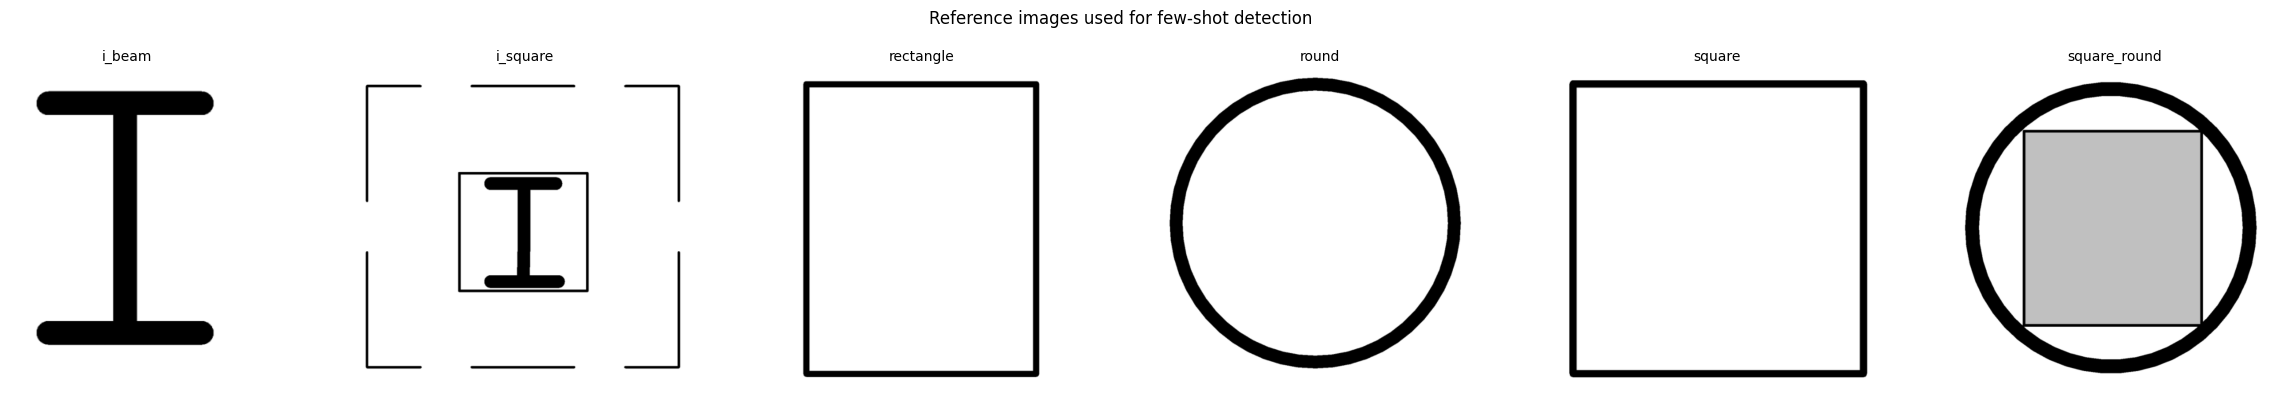

In [5]:
# Visualise all reference images
refs = agent._load_references()
import io, base64
fig, axes = plt.subplots(1, len(refs), figsize=(4 * len(refs), 4))
if len(refs) == 1: axes = [axes]
for ax, (shape, b64) in zip(axes, refs):
    img = Image.open(io.BytesIO(base64.b64decode(b64)))
    ax.imshow(img, cmap='gray')
    ax.set_title(shape, fontsize=10)
    ax.axis('off')
plt.suptitle("Reference images used for few-shot detection")
plt.tight_layout(); plt.show()

## 3 — Detect on a single ground-truth image

In [6]:
gt_images = agent.get_ground_truth_images()
for p in gt_images:
    print(Path(p).name)

i_column.png
i_sqau_column.png
i_squa_column_with_footing.png
rect_column.png
rect_column2.png
round_column.png
round_column_with_footing.png
round_squa_column.png
round_squa_column2.png
squ_round_column.png
squ_round_column2.png
squa_round_column_with_footing.png
square_column1.png
square_column3.png


In [7]:
test_image = gt_images[0]   # ← change index to test others
result = agent.detect_file(test_image, verbose=True)

print(f"\nrun_id : {result['run_id']}")
print(f"columns: {result['total_columns']}")
print(json.dumps(result['stats'], indent=2))

  Image: 306×415 px  |  Tiles: 1
  Tile 1/1  offset=(0,0)
[DEBUG tile 0] raw response:

 [{"shape": "square", "position": "top left quarter", "confidence": 0.0, "bbox": [0.12, 0.73, 0.31, 0.86]}, 
  {"shape": "rectangle", "position": "center", "confidence": 0.35, "bbox": [0.39, 0.74, 0.47, 0.87]}, 
  {"shape": "round", "position": "right edge", "confidence": 0.63, "bbox": [0.64, 0.73, 0.72, 0.86]}, 
  {"shape": "i_beam", "position": "top-left quarter", "confidence": 0.35, "bbox": [0.12, 0.73, 0.31, 0.86]}, 
  {"shape": "square", "position": "center", "confidence": 0.63, "bbox": [0.64, 0.73, 0.72, 0.87]}, 
  {"shape": "i_beam", "position": "right edge", "confidence": 0.63, "bbox": [0.64, 0.73, 0.72, 0.86]}, 
  {"shape": "i_beam", "position": "center", "confidence": 0.35, "bbox": [0.12, 0.73, 0.31, 0.87]}, 
  {"shape": "i_beam", "position": "right edge", "confidence": 0.63, "bbox": [0.64, 0.73, 0.72, 0.86]}, 
  {"shape": "i_beam", "position": "center", "confidence": 0.35, "bbox": [0.12, 

In [8]:
for det in result['detections']:
    print(f"  [{det['id']}] {det['shape']:12s}  conf={det['confidence']:.0%}  "
          f"bbox={[int(v) for v in det['bbox_page']]}  {det['notes'][:60]}")

  [1] round         conf=63%  bbox=[195, 302, 220, 356]  right edge
  [2] rectangle     conf=35%  bbox=[119, 307, 143, 361]  center
  [3] i_beam        conf=35%  bbox=[36, 302, 94, 356]  top-left quarter


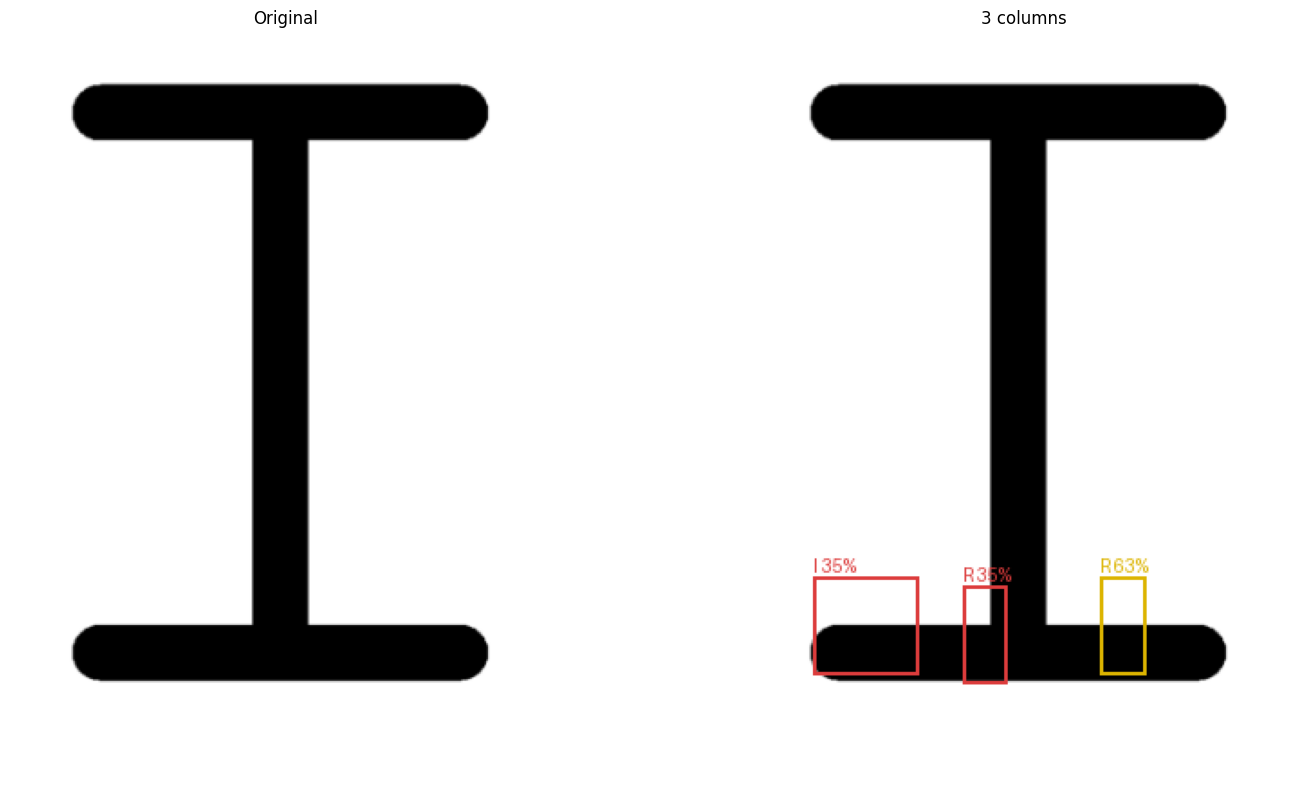

In [9]:
orig      = Image.open(test_image).convert("RGB")
annotated = agent.draw_detections(orig, result['detections'])

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes[0].imshow(orig);       axes[0].set_title("Original");                          axes[0].axis('off')
axes[1].imshow(annotated);  axes[1].set_title(f"{result['total_columns']} columns"); axes[1].axis('off')
plt.tight_layout(); plt.show()

## 4 — Detect columns in a PDF

In [24]:
importlib.reload(agent)                                                                                                                                                                                        
                  
result = agent.detect_file(
    "/home/jiezhi/Documents/floor-plan-pdf/TGCH-TD-S-200-L3-00.pdf",
    page_num=0,                                                                                                                                                                                                
    verbose=True   # watch tile-by-tile progress
  )                                                                                                                                                                                                              
print(f"columns : {result['total_columns']}")
print(json.dumps(result['stats'], indent=2))

  PDF pages: 1  →  page 0
  Image: 7021×4967 px  |  Tiles: 35
  Tile 1/35  offset=(0,0)
[DEBUG tile 0] raw response:


  Tile 2/35  offset=(1080,0)
[DEBUG tile 1] raw response:


  Tile 3/35  offset=(2160,0)
[DEBUG tile 2] raw response:


  Tile 4/35  offset=(3240,0)
[DEBUG tile 3] raw response:


  Tile 5/35  offset=(4320,0)
[DEBUG tile 4] raw response:


  Tile 6/35  offset=(5400,0)
[DEBUG tile 5] raw response:


  Tile 7/35  offset=(6480,0)
[DEBUG tile 6] raw response:
{
  "columns": [],
  "tile_notes": "no columns detected"
}

  Tile 8/35  offset=(0,1080)
[DEBUG tile 7] raw response:
{"columns": [], "tile_notes": "no columns detected"}

  Tile 9/35  offset=(1080,1080)
[DEBUG tile 8] raw response:


  Tile 10/35  offset=(2160,1080)
[DEBUG tile 9] raw response:


  Tile 11/35  offset=(3240,1080)
[DEBUG tile 10] raw response:


  Tile 12/35  offset=(4320,1080)
[DEBUG tile 11] raw response:


  Tile 13/35  offset=(5400,1080)
[DEBUG tile 12] raw response:
{
  "columns": [],
  "tile_note

In [23]:
importlib.reload(agent)

PDF_PATH = "/home/jiezhi/Documents/floor-plan-pdf/TGCH-TD-S-200-L3-00.pdf"   # ← change this
PAGE_NUM = 0

if not Path(PDF_PATH).exists():
    print(f"PDF not found: {PDF_PATH}")
else:
    result = agent.detect_file(PDF_PATH, page_num=PAGE_NUM, verbose=False)
    print(f"run_id  : {result['run_id']}")
    print(f"columns : {result['total_columns']}")
    print(json.dumps(result['stats'], indent=2))

KeyboardInterrupt: 

In [ ]:
# Render the PDF page and draw bounding boxes inline
import fitz  # PyMuPDF

if "error" not in result:
    doc = fitz.open(PDF_PATH)
    pix = doc[PAGE_NUM].get_pixmap(matrix=fitz.Matrix(agent.RENDER_DPI/72, agent.RENDER_DPI/72),
                                   colorspace=fitz.csRGB)
    doc.close()
    orig      = Image.frombytes("RGB", (pix.width, pix.height), pix.samples)
    annotated = agent.draw_detections(orig, result["detections"])

    fig, axes = plt.subplots(1, 2, figsize=(24, 14))
    axes[0].imshow(orig)
    axes[0].set_title(f"Original — page {PAGE_NUM}", fontsize=12)
    axes[0].axis("off")
    axes[1].imshow(annotated)
    axes[1].set_title(f"{result['total_columns']} columns detected", fontsize=12)
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()

    # Per-detection table
    if result["detections"]:
        print(f"\n{'id':>4}  {'shape':12}  {'conf':>6}  {'bbox (page px)':30}  notes")
        print("-" * 85)
        for d in result["detections"]:
            bb = [int(v) for v in d["bbox_page"]]
            print(f"{d['id']:>4}  {d['shape']:12}  {d['confidence']:.0%}  {str(bb):30}  {d['notes'][:40]}")

## 5 — Query the SQLite memory

In [17]:
# Overall stats
print(json.dumps(agent.memory_stats(), indent=2))

{
  "total_runs": 2,
  "total_columns": 0,
  "by_shape": {},
  "avg_confidence": 0.0
}


In [18]:
# List recent runs (copy a run_id from here to use in memory_clear below)
runs = agent.memory_runs(limit=10)
print(f"{'run_id':>38}  {'file':<30} {'page':>5} {'cols':>5}  timestamp")
print("-" * 95)
for r in runs:
    print(f"{r['run_id']:>38}  {Path(r['file_path']).name:<30} "
          f"{r['page_num']:>5} {r['total_cols']:>5}  {r['timestamp'][:19]}")

                                run_id  file                            page  cols  timestamp
-----------------------------------------------------------------------------------------------
  00c7409f-7c71-4d22-b4c4-062b2cea74cb  TGCH-TD-S-200-L3-00.pdf            0     0  2026-03-25T19:38:18
  2984d85d-936d-4543-ab6d-51067b5ad23f  i_column.png                       0     0  2026-03-25T19:09:23


In [19]:
# Search: all circle columns with confidence >= 80%
rows = agent.memory_search(shape="circle", min_confidence=0.8)
print(f"Found {len(rows)} circle columns with conf >= 80%")
for r in rows[:10]:
    print(f"  conf={r['confidence']:.0%}  file={Path(r['file_path']).name}  notes={r['notes'][:50]}")

Found 0 circle columns with conf >= 80%


## 6 — Clear memory

Use this to remove false positives or contaminated runs.

In [ ]:
# Delete one specific run by run_id (paste the run_id from Section 5 above)
RUN_TO_DELETE = "paste-run-id-here"

result = agent.memory_clear(run_id=RUN_TO_DELETE)
print(f"Deleted: {result}")

In [ ]:
# ⚠️  Wipe ALL memory — uncomment and run deliberately
# result = agent.memory_clear()
# print(f"Cleared: {result}")

## 7 — Agentic Q&A

In [ ]:
session = agent.AgentSession()
print(session.ask("Check the status and list available ground-truth images."))

In [ ]:
print(session.ask("Run detection on the first ground-truth image. What shapes were found?"))

In [ ]:
print(session.ask("Search memory for all circle columns with confidence above 80%."))

## 8 — Iterative Feedback Loop (moondream)

**Workflow:**
1. Run moondream detection — it detects *some* columns, possibly imperfect
2. View annotated image, identify missed / wrong detections
3. Call `add_correction()` to teach the model
4. Re-run — corrections are injected into the prompt for this tile
5. Repeat until detection is satisfactory

`add_correction(tile_hash, action, shape, bbox, notes)`
- `action='confirm'` — this detection is correct (reinforces it)
- `action='reject'`  — this was a false positive (prevents it next run)
- `action='add'`     — missed column; supply bbox + shape

In [ ]:
importlib.reload(agent)

PDF_PATH = "/home/jiezhi/Documents/floor-plan-pdf/84f2df7c-3ddc-4516-bdd8-090cfe5e5c93.pdf"
PAGE_NUM = 0

result = agent.detect_file(
    PDF_PATH, page_num=PAGE_NUM,
    model="moondream:latest",
    save_image="moondream_detections.png",
    verbose=True
)
print(f"\nTotal detections: {result['total_columns']}")
print(f"By shape: {result['stats']['by_shape']}")
print(f"Run ID:   {result['run_id']}")
print()

# Print detection table with tile_hash (needed for corrections)
if result['detections']:
    print(f"{'id':>3}  {'shape':15}  {'conf':>5}  {'bbox (page px)':30}  tile_hash")
    print("-" * 90)
    for d in result['detections']:
        bb = [int(v) for v in d['bbox_page']]
        print(f"{d['id']:>3}  {d['shape']:15}  {d['confidence']:.0%}  {str(bb):30}  {d['tile_hash']}")
else:
    print("No detections — try on the other PDF or add corrections below.")

In [ ]:
import fitz

# View original + moondream annotated side by side
doc  = fitz.open(PDF_PATH)
pix  = doc[PAGE_NUM].get_pixmap(matrix=fitz.Matrix(agent.RENDER_DPI/72, agent.RENDER_DPI/72),
                                colorspace=fitz.csRGB)
doc.close()
orig      = Image.frombytes("RGB", (pix.width, pix.height), pix.samples)
annotated = agent.draw_detections(orig, result['detections'])

fig, axes = plt.subplots(1, 2, figsize=(20, 10))
axes[0].imshow(orig);       axes[0].set_title("Original floor plan"); axes[0].axis("off")
axes[1].imshow(annotated);  axes[1].set_title(f"moondream: {result['total_columns']} detections");  axes[1].axis("off")
plt.tight_layout(); plt.show()
print("Green = conf ≥ 80%  |  Yellow = 50–79%  |  Red = < 50%")

In [ ]:
# ── TEACH THE MODEL ──────────────────────────────────────────────────────────
# After viewing the annotated image above:
#   1. Copy tile_hash from the table printed above
#   2. Use pixel coordinates from the original image (you can read them from matplotlib)
#   3. Add corrections — these are stored in memory.json + detections.db

TILE_HASH = "f21e45ec2ffdf57b"   # ← paste tile_hash from detection table above

# Example: confirm a correct detection
# agent.add_correction(TILE_HASH, action="confirm", shape="round",
#                      bbox=[516, 506, 581, 567], notes="correct round column center-right")

# Example: reject a false positive
# agent.add_correction(TILE_HASH, action="reject", shape="square",
#                      bbox=[202, 498, 339, 597], notes="this is a room label, not a column")

# Example: teach a missed column (inspect image with matplotlib to get pixel coords)
# agent.add_correction(TILE_HASH, action="add", shape="square",
#                      bbox=[x1, y1, x2, y2], notes="square column top-left area, missed by model")

# View all recorded corrections for this tile
corrections = agent.list_corrections(tile_hash=TILE_HASH)
print(f"Corrections for tile {TILE_HASH}: {len(corrections)}")
for c in corrections:
    print(f"  [{c['action']:8s}] {c['shape']:15} bbox=[{c['bbox_x1']:.0f},{c['bbox_y1']:.0f},{c['bbox_x2']:.0f},{c['bbox_y2']:.0f}]  {c['notes']}")

In [ ]:
# ── RE-RUN WITH CORRECTIONS INJECTED ─────────────────────────────────────────
# After adding corrections above, re-run the same PDF.
# The model will receive your corrections as part of the prompt context.

importlib.reload(agent)
result2 = agent.detect_file(
    PDF_PATH, page_num=PAGE_NUM,
    model="moondream:latest",
    save_image="moondream_corrected.png",
    verbose=True
)
print(f"\nRound 2 — Total detections: {result2['total_columns']}")
for d in result2['detections']:
    bb = [int(v) for v in d['bbox_page']]
    print(f"  [{d['id']}] {d['shape']:15}  conf={d['confidence']:.0%}  bbox={bb}")

In [ ]:
# ── SEARCH SIMILAR TILES (vector search) ─────────────────────────────────────
# Find tiles with similar descriptions across past runs — useful to bulk-apply
# corrections to structurally similar parts of the floor plan.

results = agent.search_similar_tiles("square column grid intersection", limit=5)
print(f"Similar tiles found: {len(results)}")
for r in results:
    print(f"  hash={r['tile_hash']}  tile={r['tile_index']}  file={Path(r['file_path']).name if r['file_path'] else '?'}")
    print(f"  description: {r['description'][:100]}")

print()
print("=== memory.json summary ===")
mem = agent._mjson_load()
print(f"Version: {mem['version']}")
print(f"Tiles with corrections: {len(mem['corrections'])}")
for h, corrs in mem['corrections'].items():
    print(f"  {h}: {len(corrs)} correction(s) — {[c['action'] for c in corrs]}")